# Four-Agent Comparison (B0–B3) — Final Results

**Purpose:** Load all per-day test results from nb0–nb3 and produce:
1. Four metric tables (Sharpe, Sortino, Max DD, P&L-to-MAP) in the format of Falces Marín et al. (2022)
2. Statistical tests: Kruskal-Wallis (all four) + Mann-Whitney U (B2 vs B3)
3. Key thesis plots: MaxDD comparison, Sharpe over time, Pareto frontier, λ trajectory
4. Days-best summary table

**Prerequisites:** Run nb0 → nb1 → nb2 → nb3 in order.

**Required CSVs in `results/`:**
- `b0_test_results.csv`
- `b1_test_results.csv`
- `b2_alpha{X}_test_results.csv`  (for best α)
- `b3_test_results.csv`
- `b3_callback_history.json`
- `b2_best_alpha.txt`

In [1]:
import sys
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import kruskal, mannwhitneyu

PROJECT_ROOT = next(
    (p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
     if (p / "procs").exists()),
    pathlib.Path.cwd(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from procs.gym.experiment_config import ReplayExperimentConfig

cfg = ReplayExperimentConfig()
print(f"Results dir: {cfg.results_dir}")

Results dir: C:\Users\john-\Documents\Thesis_AI4T\results


## Section 1 — Load All Results

In [2]:
df_b0 = pd.read_csv(cfg.result_path("b0_test_results.csv"), index_col="Day")
df_b1 = pd.read_csv(cfg.result_path("b1_test_results.csv"), index_col="Day")
df_b3 = pd.read_csv(cfg.result_path("b3_test_results.csv"), index_col="Day")

with open(cfg.result_path("b2_best_alpha.txt")) as f:
    best_alpha = float(f.read().strip())
print(f"B2 best α = {best_alpha}")

b2_primary_path = cfg.result_path("b2_test_results.csv")
if b2_primary_path.exists():
    df_b2 = pd.read_csv(b2_primary_path, index_col="Day")
else:
    df_b2 = pd.read_csv(cfg.result_path(f"b2_alpha{best_alpha}_test_results.csv"), index_col="Day")

# Load all three B2 alphas for Pareto plot
ALPHAS = [0.1, 1.0, 10.0]
b2_all = {}
for alpha in ALPHAS:
    try:
        b2_all[alpha] = pd.read_csv(
            cfg.result_path(f"b2_alpha{alpha}_test_results.csv"), index_col="Day"
        )
    except FileNotFoundError:
        print(f"Missing: b2_alpha{alpha}_test_results.csv")

# CVaR threshold d
with open(cfg.result_path("cvar_threshold_d.txt")) as f:
    lines = f.read().strip().split()
    d_threshold = float(lines[0])


AGENT_DFS = {"B0": df_b0, "B1": df_b1, "B2": df_b2, "B3": df_b3}
REQUIRED_RESULT_COLUMNS = ["Sharpe", "Sortino", "Max DD", "P&L-to-MAP", "Final PnL", "Mean |q|"]
expected_dates = list(df_b0.index)
if len(expected_dates) != 23:
    raise ValueError(f"Expected 23 held-out test days, found {len(expected_dates)} in B0 results.")

for name, df in AGENT_DFS.items():
    missing_cols = [col for col in REQUIRED_RESULT_COLUMNS if col not in df.columns]
    if missing_cols:
        raise ValueError(f"{name} results are missing required columns: {missing_cols}")
    if list(df.index) != expected_dates:
        raise ValueError(f"{name} result dates do not match B0 exactly; refusing misaligned comparison.")

for alpha, df in b2_all.items():
    if list(df.index) != expected_dates:
        raise ValueError(f"B2 alpha={alpha} result dates do not match B0 exactly.")

print(f"Loaded {len(df_b0)} / {len(df_b1)} / {len(df_b2)} / {len(df_b3)} test days for B0/B1/B2/B3")
print(f"CVaR threshold d = {d_threshold:.6f}")

B2 best α = 1.0
Loaded 23 / 23 / 23 / 23 test days for B0/B1/B2/B3
CVaR threshold d = 0.000667


## Section 2 — Four Metric Tables

Format following Falces Marín et al. (2022) Tables 2–5:
- Rows: one per test day
- Columns: B0, B1, B2, B3
- Summary rows: Days best, Median, Mean, Std Dev

In [3]:
METRICS_CONFIG = {
    "Sharpe":     {"col": "Sharpe",     "higher_better": True},
    "Sortino":    {"col": "Sortino",    "higher_better": True},
    "Max DD":     {"col": "Max DD",     "higher_better": False},
    "P&L-to-MAP": {"col": "P&L-to-MAP", "higher_better": True},
}

AGENT_NAMES = list(AGENT_DFS.keys())


def build_metric_table(dfs: dict, col: str, higher_better: bool) -> pd.DataFrame:
    """Build per-day table + summary rows in Falces Marín style."""
    table = pd.DataFrame({name: df[col] for name, df in dfs.items()})
    table.index.name = "Day"

    if higher_better:
        days_best = table.apply(lambda row: row.idxmax(), axis=1).value_counts()
    else:
        days_best = table.apply(lambda row: row.idxmin(), axis=1).value_counts()

    days_best = days_best.reindex(AGENT_NAMES, fill_value=0)

    summary = pd.DataFrame(
        {
            name: {
                "Days best": int(days_best[name]),
                "Median":    table[name].median(),
                "Mean":      table[name].mean(),
                "Std Dev":   table[name].std(),
            }
            for name in AGENT_NAMES
        }
    ).T

    return pd.concat([table, summary.T])


pd.set_option("display.float_format", "{:.4f}".format)

for metric_name, props in METRICS_CONFIG.items():
    tbl = build_metric_table(AGENT_DFS, props["col"], props["higher_better"])
    tbl.to_csv(cfg.result_path(f"table_{metric_name.replace(' ', '_').lower()}.csv"))
    print(f"\n{'='*70}")
    print(f"  {metric_name}  ({'higher is better' if props['higher_better'] else 'lower is better'})")
    print(f"{'='*70}")
    print(tbl.to_string())


  Sharpe  (higher is better)
                B0     B1     B2     B3
2025-01-07  0.0752 0.0140 0.0348 0.0348
2025-01-08  0.0926 0.0094 0.0112 0.0177
2025-01-09  0.0821 0.0091 0.0059 0.0051
2025-01-10  0.0764 0.0087 0.0084 0.0080
2025-01-11  0.0436 0.0200 0.0176 0.0165
2025-01-12  0.0442 0.0194 0.0141 0.0168
2025-01-13  0.0829 0.0114 0.0059 0.0049
2025-01-14  0.0701 0.0135 0.0185 0.0230
2025-01-15  0.0637 0.0133 0.0316 0.0378
2025-01-16  0.0779 0.0183 0.0380 0.0380
2025-01-17  0.0165 0.0148 0.0345 0.0345
2025-01-18  0.0129 0.0152 0.0333 0.0333
2025-01-19  0.0088 0.0078 0.0306 0.0306
2025-01-20  0.0160 0.0087 0.0176 0.0197
2025-01-21  0.1258 0.0045 0.0096 0.0134
2025-01-22  0.0426 0.0145 0.0378 0.0378
2025-01-23  0.0712 0.0129 0.0183 0.0368
2025-01-24  0.0640 0.0179 0.0239 0.0309
2025-01-25  0.0457 0.0167 0.0207 0.0351
2025-01-26  0.0275 0.0261 0.0299 0.0387
2025-01-27  0.0998 0.0083 0.0050 0.0043
2025-01-28  0.0574 0.0132 0.0113 0.0097
2025-01-29  0.0481 0.0114 0.0075 0.0069
Days best 

## Section 3 — Statistical Tests

**Kruskal-Wallis** (non-parametric, no normality assumption) across B0–B3 per metric.

**Mann-Whitney U** (pairwise) for the key comparison: B2 vs B3 per metric.

In [4]:
print("=" * 60)
print("Kruskal-Wallis H-test across B0, B1, B2, B3  (n=23 per agent)")
print("=" * 60)
for metric_name, props in METRICS_CONFIG.items():
    col = props["col"]
    groups = [df[col].dropna().values for df in AGENT_DFS.values()]
    stat, p = kruskal(*groups)
    sig = "**" if p < 0.01 else ("*" if p < 0.05 else "ns")
    print(f"  {metric_name:12s}: H={stat:.3f}  p={p:.4f}  {sig}")

print()
print("=" * 60)
print("Mann-Whitney U: B2 vs B3  (two-sided)")
print("=" * 60)
for metric_name, props in METRICS_CONFIG.items():
    col = props["col"]
    u_stat, p = mannwhitneyu(
        df_b2[col].dropna().values,
        df_b3[col].dropna().values,
        alternative="two-sided",
    )
    sig = "**" if p < 0.01 else ("*" if p < 0.05 else "ns")
    better = "B3" if (
        (props["higher_better"] and df_b3[col].mean() > df_b2[col].mean()) or
        (not props["higher_better"] and df_b3[col].mean() < df_b2[col].mean())
    ) else "B2"
    print(f"  {metric_name:12s}: U={u_stat:.0f}  p={p:.4f}  {sig}  [{better} better]")

Kruskal-Wallis H-test across B0, B1, B2, B3  (n=23 per agent)
  Sharpe      : H=34.023  p=0.0000  **
  Sortino     : H=25.131  p=0.0000  **
  Max DD      : H=19.849  p=0.0002  **
  P&L-to-MAP  : H=14.016  p=0.0029  **

Mann-Whitney U: B2 vs B3  (two-sided)
  Sharpe      : U=228  p=0.4289  ns  [B3 better]
  Sortino     : U=263  p=0.9825  ns  [B3 better]
  Max DD      : U=286  p=0.6445  ns  [B3 better]
  P&L-to-MAP  : U=231  p=0.4684  ns  [B3 better]


## Section 4 — Plot 1: Per-Day MaxDD — B2 vs B3

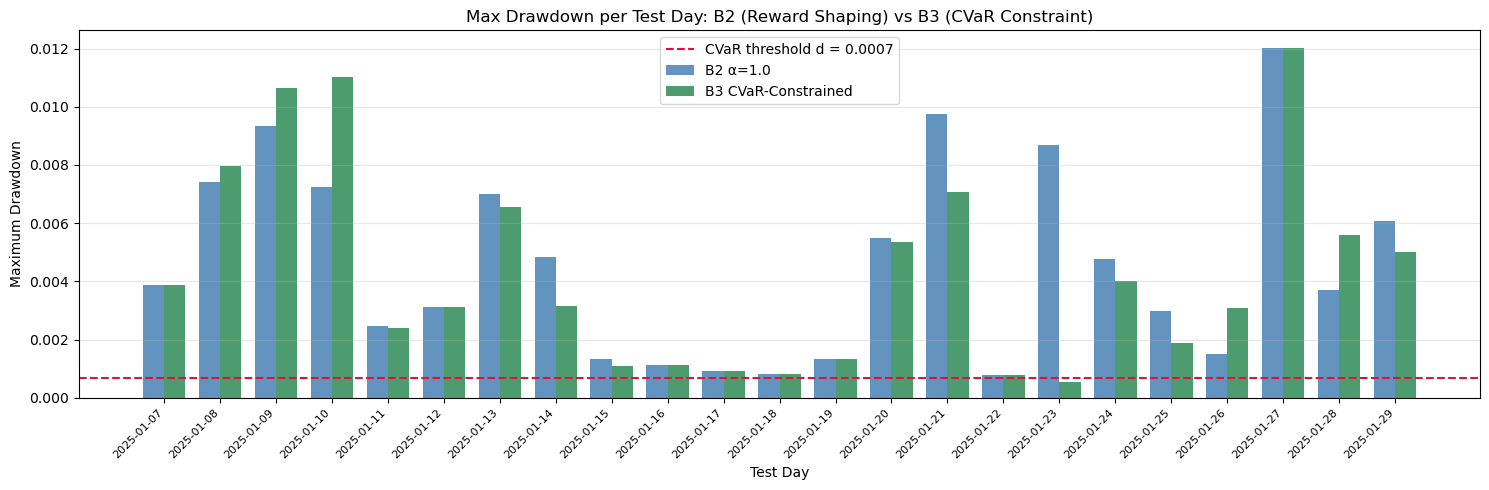

In [5]:
x = np.arange(len(df_b3))
width = 0.38

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - width/2, df_b2["Max DD"].values, width, label=f"B2 α={best_alpha}", color="steelblue", alpha=0.85)
ax.bar(x + width/2, df_b3["Max DD"].values, width, label="B3 CVaR-Constrained", color="seagreen",  alpha=0.85)
ax.axhline(d_threshold, color="crimson", linestyle="--", linewidth=1.5,
           label=f"CVaR threshold d = {d_threshold:.4f}")

ax.set_xticks(x)
ax.set_xticklabels([str(idx) for idx in df_b3.index], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Test Day")
ax.set_ylabel("Maximum Drawdown")
ax.set_title("Max Drawdown per Test Day: B2 (Reward Shaping) vs B3 (CVaR Constraint)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(str(cfg.result_path("plot1_maxdd_b2_vs_b3.png")), dpi=150, bbox_inches="tight")
plt.show()

## Section 5 — Plot 2: Per-Day Sharpe — B0, B1, B3

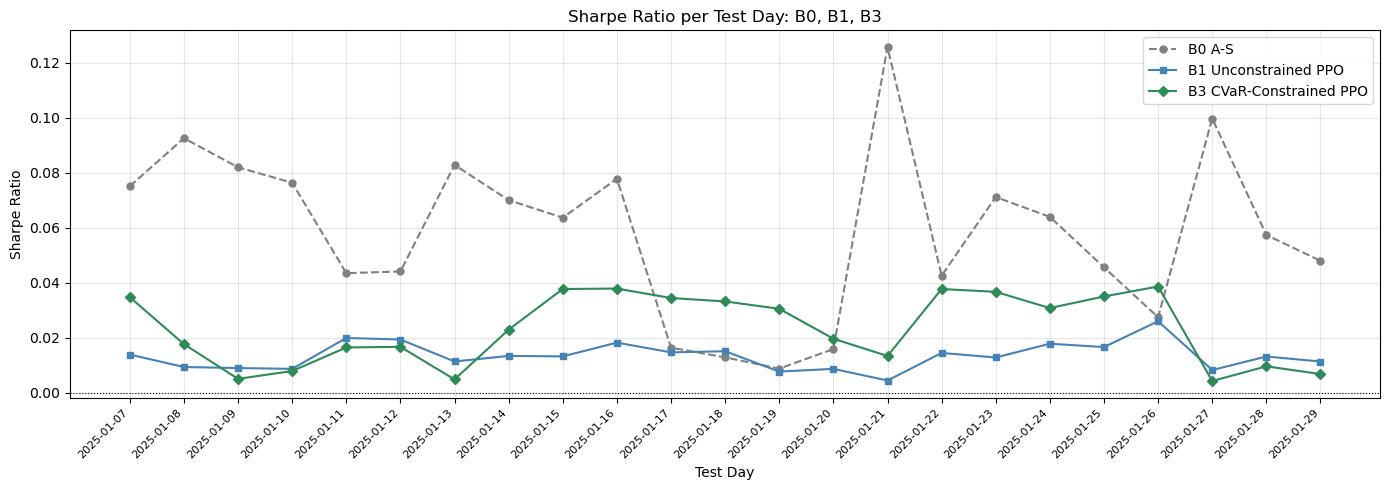

In [6]:
test_idx = range(len(df_b3))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_idx, df_b0["Sharpe"].values, "o--", color="gray",      linewidth=1.5, markersize=5, label="B0 A-S")
ax.plot(test_idx, df_b1["Sharpe"].values, "s-",  color="steelblue", linewidth=1.5, markersize=5, label="B1 Unconstrained PPO")
ax.plot(test_idx, df_b3["Sharpe"].values, "D-",  color="seagreen",  linewidth=1.5, markersize=5, label="B3 CVaR-Constrained PPO")
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")

ax.set_xticks(list(test_idx))
ax.set_xticklabels([str(idx) for idx in df_b3.index], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Test Day")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Sharpe Ratio per Test Day: B0, B1, B3")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(cfg.result_path("plot2_sharpe_per_day.png")), dpi=150, bbox_inches="tight")
plt.show()

## Section 6 — Plot 3: Pareto Frontier

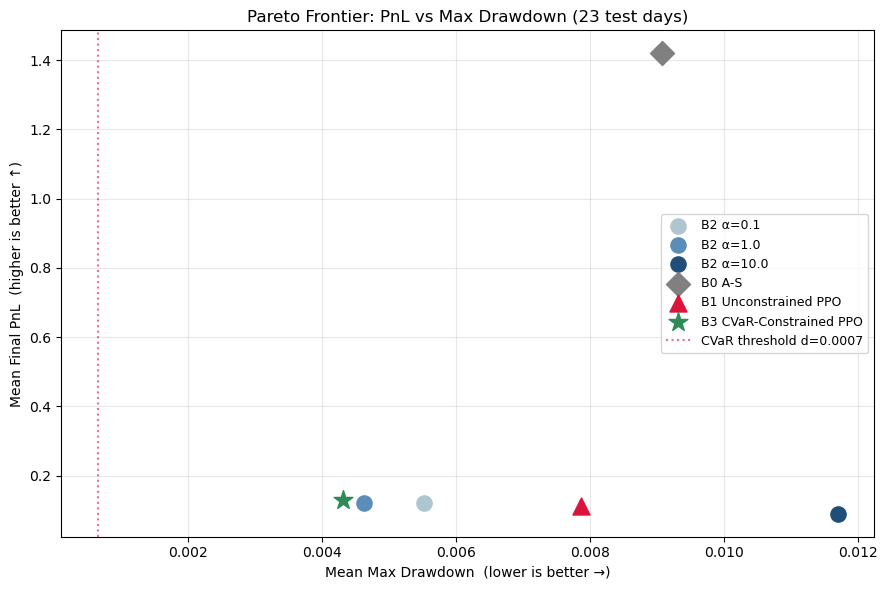

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

colors_b2 = ["#aec6cf", "#5b8db8", "#1f4e79"]
for (alpha, df_a), color in zip(sorted(b2_all.items()), colors_b2):
    ax.scatter(df_a["Max DD"].mean(), df_a["Final PnL"].mean(),
               s=120, color=color, zorder=5,
               label=f"B2 α={alpha}")

ax.scatter(df_b0["Max DD"].mean(), df_b0["Final PnL"].mean(),
           s=150, color="gray", marker="D", zorder=5,
           label="B0 A-S")
ax.scatter(df_b1["Max DD"].mean(), df_b1["Final PnL"].mean(),
           s=150, color="crimson", marker="^", zorder=5,
           label="B1 Unconstrained PPO")
ax.scatter(df_b3["Max DD"].mean(), df_b3["Final PnL"].mean(),
           s=200, color="seagreen", marker="*", zorder=6,
           label="B3 CVaR-Constrained PPO")

ax.axvline(d_threshold, color="crimson", linestyle=":", alpha=0.6,
           label=f"CVaR threshold d={d_threshold:.4f}")

ax.set_xlabel("Mean Max Drawdown  (lower is better →)")
ax.set_ylabel("Mean Final PnL  (higher is better ↑)")
ax.set_title("Pareto Frontier: PnL vs Max Drawdown (23 test days)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(cfg.result_path("plot3_pareto_frontier.png")), dpi=150, bbox_inches="tight")
plt.show()

## Section 7 — Plot 4: λ Trajectory During B3 Training

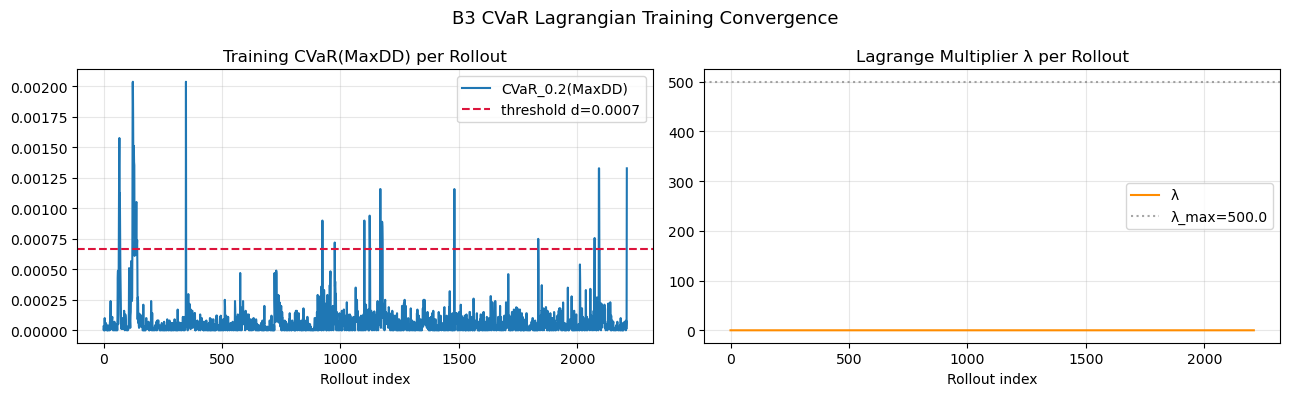

Final λ = 0.0099  (λ_max=500.0)
Final CVaR = 0.001328  (threshold d=0.000667)
Constraint VIOLATED at convergence.


In [8]:
try:
    with open(cfg.result_path("b3_callback_history.json")) as f:
        cb_hist = json.load(f)

    lambda_hist = cb_hist["lambda_history"]
    cvar_hist   = cb_hist["cvar_history"]
    d_hist      = cb_hist["dd_threshold"]
    lmax_hist   = cb_hist["lambda_max"]

    rollouts = range(len(lambda_hist))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(rollouts, cvar_hist, label=f"CVaR_0.2(MaxDD)")
    axes[0].axhline(d_hist, color="crimson", linestyle="--",
                    label=f"threshold d={d_hist:.4f}")
    axes[0].set_title("Training CVaR(MaxDD) per Rollout")
    axes[0].set_xlabel("Rollout index")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(rollouts, lambda_hist, color="darkorange", label="λ")
    axes[1].axhline(lmax_hist, color="gray", linestyle=":", alpha=0.7,
                    label=f"λ_max={lmax_hist}")
    axes[1].set_title("Lagrange Multiplier λ per Rollout")
    axes[1].set_xlabel("Rollout index")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("B3 CVaR Lagrangian Training Convergence", fontsize=13)
    plt.tight_layout()
    plt.savefig(str(cfg.result_path("plot4_lambda_trajectory.png")), dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Final λ = {lambda_hist[-1]:.4f}  (λ_max={lmax_hist})")
    print(f"Final CVaR = {cvar_hist[-1]:.6f}  (threshold d={d_hist:.6f})")
    print(f"Constraint {'SATISFIED' if cvar_hist[-1] <= d_hist else 'VIOLATED'} at convergence.")
except FileNotFoundError:
    print("b3_callback_history.json not found — run nb3 first.")

## Section 8 — Days-Best Summary Table

Following Falces Marín et al. (2022) Table 6: count of days each agent achieved the best score.

In [9]:
days_best_rows = []
for metric_name, props in METRICS_CONFIG.items():
    col = props["col"]
    table = pd.DataFrame({name: df[col] for name, df in AGENT_DFS.items()})
    if props["higher_better"]:
        winner = table.apply(lambda row: row.idxmax(), axis=1)
    else:
        winner = table.apply(lambda row: row.idxmin(), axis=1)
    counts = winner.value_counts().reindex(AGENT_NAMES, fill_value=0)
    row = dict(counts)
    row["Metric"] = metric_name
    days_best_rows.append(row)

df_days_best = pd.DataFrame(days_best_rows).set_index("Metric")[AGENT_NAMES]
df_days_best.loc["TOTAL"] = df_days_best.sum()

print("=" * 55)
print("Days-Best Summary (out of 23 test days)")
print("=" * 55)
print(df_days_best.to_string())

df_days_best.to_csv(cfg.result_path("comparison_table.csv"))
print(f"\nSaved → {cfg.result_path('comparison_table.csv')}")

Days-Best Summary (out of 23 test days)
            B0  B1  B2  B3
Metric                    
Sharpe      18   0   3   2
Sortino     18   0   5   0
Max DD       4   4   9   6
P&L-to-MAP  11   0   6   6
TOTAL       51   4  23  14

Saved → C:\Users\john-\Documents\Thesis_AI4T\results\comparison_table.csv


## Section 9 — Overall Summary Table

In [10]:
summary_rows = []
for metric_name, props in METRICS_CONFIG.items():
    col = props["col"]
    for agent_name, df in AGENT_DFS.items():
        summary_rows.append({
            "Agent":  agent_name,
            "Metric": metric_name,
            "Mean":   df[col].mean(),
            "Std":    df[col].std(),
            "Median": df[col].median(),
        })

df_summary = pd.DataFrame(summary_rows)
pivot = df_summary.pivot_table(
    index="Metric", columns="Agent",
    values="Mean", aggfunc="first"
)[AGENT_NAMES]

pd.set_option("display.float_format", "{:.4f}".format)
print("=" * 65)
print("Overall Mean per Metric (across 23 test days)")
print("=" * 65)
print(pivot.reindex(["Sharpe", "Sortino", "Max DD", "P&L-to-MAP"]).to_string())

print("\n(Lower is better for Max DD; higher is better for all others.)")

Overall Mean per Metric (across 23 test days)
Agent          B0     B1     B2     B3
Metric                                
Sharpe     0.0585 0.0134 0.0203 0.0232
Sortino    0.0293 0.0051 0.0060 0.0061
Max DD     0.0091 0.0079 0.0046 0.0043
P&L-to-MAP 1.6574 0.3730 2.4719 3.5853

(Lower is better for Max DD; higher is better for all others.)
